#**Tugas 12: Classification & Clustering - Pengantar Data Sains**

> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 13**

## Latihan 1 — Logistic Regression

Gunakan dataset Breast Cancer yang sama.

1. Pilih hanya 5 fitur berikut:
   - `mean radius`
   - `mean texture`
   - `mean perimeter`
   - `mean area`
   - `mean smoothness`

2. Bangun model logistic regression.
3. Evaluasi model dengan:
   - confusion matrix,
   - accuracy,
   - precision,
   - recall,
   - F1-score,
   - ROC-AUC.
4. Bandingkan hasilnya dengan model yang menggunakan semua fitur.
5. Jelaskan apakah model dengan 5 fitur masih cukup baik.

## Latihan 2 — Threshold

Gunakan model logistic regression dengan 5 fitur dari Latihan 1.

1. Bandingkan threshold 0.3, 0.5, dan 0.7.
2. Catat perubahan precision dan recall.
3. Jelaskan threshold mana yang lebih sesuai jika tujuan utama adalah mengurangi false negative.

## Latihan 3 — K-Means

Gunakan dataset Iris.

1. Jalankan k-means dengan $K=2$, $K=3$, dan $K=4$.
2. Hitung silhouette score untuk masing-masing $K$.
3. Bandingkan hasilnya.
4. Menurut Anda, jumlah cluster mana yang paling masuk akal?
5. Jelaskan alasan Anda.

## Latihan 4 — Interpretasi Cluster

Gunakan hasil k-means Iris dengan $K=3$.

1. Buat tabel rata-rata fitur untuk setiap cluster.
2. Tentukan cluster mana yang memiliki ukuran petal paling besar.
3. Tentukan cluster mana yang memiliki ukuran petal paling kecil.
4. Jelaskan kemungkinan karakteristik masing-masing cluster.

## **Latihan 1 — Logistic Regression**

Pada latihan ini dilakukan pemodelan classification menggunakan algoritma logistic regression pada dataset Breast Cancer Wisconsin dari scikit-learn. Dataset ini berisi berbagai karakteristik numerik sel tumor yang digunakan untuk memprediksi apakah tumor termasuk kategori benign atau malignant. Karena target yang diprediksi berbentuk kategori biner, maka pendekatan yang digunakan termasuk supervised learning classification.

Pada latihan ini hanya dipilih lima fitur utama, yaitu `mean radius`, `mean texture`, `mean perimeter`, `mean area`, dan `mean smoothness`. Pemilihan subset fitur dilakukan untuk melihat apakah model masih mampu melakukan klasifikasi dengan baik meskipun informasi yang digunakan lebih sedikit dibandingkan model penuh.

Tahapan analisis dimulai dengan memuat dataset, memilih fitur yang digunakan, kemudian membagi data menjadi training set dan testing set menggunakan `train_test_split`. Proses pembagian data menggunakan `stratify=y` agar proporsi kelas benign dan malignant tetap seimbang pada data training maupun testing. Setelah itu dilakukan standardisasi fitur menggunakan `StandardScaler` karena logistic regression sensitif terhadap perbedaan skala antarvariabel numerik.

Model logistic regression kemudian dibangun menggunakan `Pipeline` agar proses preprocessing dan pemodelan berjalan secara konsisten serta menghindari data leakage. Setelah model dilatih, dilakukan prediksi pada data testing untuk memperoleh label prediksi dan probabilitas prediksi kelas malignant.

Evaluasi model dilakukan menggunakan beberapa evaluation metrics classification agar performa model dapat dianalisis dari berbagai sudut pandang. Penggunaan banyak metrik penting karena accuracy saja tidak selalu cukup untuk menggambarkan kualitas model classification.

Evaluasi yang digunakan meliputi:
- Confusion Matrix
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Selain membangun model menggunakan lima fitur, pada latihan ini juga dibuat model logistic regression menggunakan seluruh fitur dataset Breast Cancer. Tujuannya adalah membandingkan performa kedua model untuk melihat apakah pengurangan jumlah fitur menyebabkan penurunan performa yang signifikan atau tidak.

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Random state
RANDOM_STATE = 42

In [8]:
# Load dataset Breast Cancer
breast_cancer = load_breast_cancer()
X_full = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)

# 1 = malignant
# 0 = benign
y = pd.Series((breast_cancer.target == 0).astype(int), name="diagnosis_malignant")

X_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [12]:
# Memilih 5 fitur
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]
X_5 = X_full[selected_features]

# Train-test split untuk model 5 fitur
X_train_5, X_test_5, y_train, y_test = train_test_split(
    X_5,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Ukuran data training:")
print(X_train_5.shape)
print("Ukuran data testing:")
print(X_test_5.shape)

Ukuran data training:
(426, 5)
Ukuran data testing:
(143, 5)


In [13]:
# Pipeline logistic regression (5 fitur)
logreg_5 = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Training model
logreg_5.fit(X_train_5, y_train)

# Prediksi
y_pred_5 = logreg_5.predict(X_test_5)

# Probabilitas kelas 1 (malignant)
y_prob_5 = logreg_5.predict_proba(X_test_5)[:, 1]

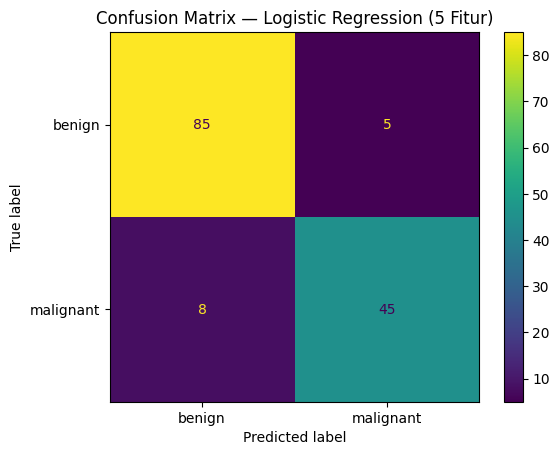

In [15]:
# Confusion Matrix
cm_5 = confusion_matrix(y_test, y_pred_5)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_5,
    display_labels=["benign", "malignant"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (5 Fitur)")
plt.grid(False)
plt.show()

In [16]:
# Evaluasi model 5 fitur
print("Accuracy :", round(accuracy_score(y_test, y_pred_5), 4))
print("Precision:", round(precision_score(y_test, y_pred_5), 4))
print("Recall   :", round(recall_score(y_test, y_pred_5), 4))
print("F1-score :", round(f1_score(y_test, y_pred_5), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_5), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_5))

Accuracy : 0.9091
Precision: 0.9
Recall   : 0.8491
F1-score : 0.8738
ROC-AUC  : 0.9805

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        90
           1       0.90      0.85      0.87        53

    accuracy                           0.91       143
   macro avg       0.91      0.90      0.90       143
weighted avg       0.91      0.91      0.91       143



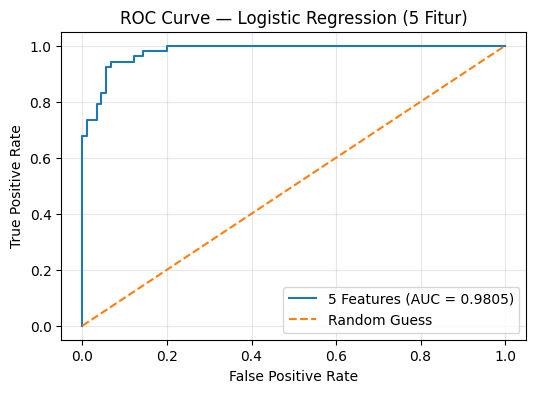

In [18]:
# ROC Curve
fpr_5, tpr_5, thresholds_5 = roc_curve(y_test, y_prob_5)

plt.figure(figsize=(6, 4))
plt.plot(
    fpr_5,
    tpr_5,
    label=f"5 Features (AUC = {roc_auc_score(y_test, y_prob_5):.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression (5 Fitur)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# MODEL PEMBANDING — SEMUA FITUR
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

# Pipeline logistic regression (semua fitur)
logreg_full = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Training model semua fitur
logreg_full.fit(X_train_full, y_train_full)

# Prediksi model semua fitur
y_pred_full = logreg_full.predict(X_test_full)
y_prob_full = logreg_full.predict_proba(X_test_full)[:, 1]

In [21]:
# Evaluasi model semua fitur
print("Accuracy :", round(accuracy_score(y_test_full, y_pred_full), 4))
print("Precision:", round(precision_score(y_test_full, y_pred_full), 4))
print("Recall   :", round(recall_score(y_test_full, y_pred_full), 4))
print("F1-score :", round(f1_score(y_test_full, y_pred_full), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test_full, y_prob_full), 4))

print("\nClassification Report:")
print(classification_report(y_test_full, y_pred_full))

Accuracy : 0.965
Precision: 0.98
Recall   : 0.9245
F1-score : 0.9515
ROC-AUC  : 0.9962

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [23]:
# Perbandingan hasil evaluasi
hasil_perbandingan = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "5 Features": [
        accuracy_score(y_test, y_pred_5),
        precision_score(y_test, y_pred_5),
        recall_score(y_test, y_pred_5),
        f1_score(y_test, y_pred_5),
        roc_auc_score(y_test, y_prob_5)
    ],
    "All Features": [
        accuracy_score(y_test_full, y_pred_full),
        precision_score(y_test_full, y_pred_full),
        recall_score(y_test_full, y_pred_full),
        f1_score(y_test_full, y_pred_full),
        roc_auc_score(y_test_full, y_prob_full)
    ]
})
hasil_perbandingan = hasil_perbandingan.round(4)

print("Perbandingan Model:")
print(hasil_perbandingan)

Perbandingan Model:
      Metric  5 Features  All Features
0   Accuracy      0.9091        0.9650
1  Precision      0.9000        0.9800
2     Recall      0.8491        0.9245
3   F1-Score      0.8738        0.9515
4    ROC-AUC      0.9805        0.9962


## Interpretasi Hasil Latihan 1

### 1. Struktur Dataset

Berdasarkan hasil `X_full.info()`, dataset Breast Cancer memiliki 569 observasi dan 30 variabel numerik bertipe `float64`. Seluruh variabel tidak memiliki missing values sehingga dataset sudah dalam kondisi bersih dan siap digunakan untuk proses machine learning tanpa perlu tahap imputasi data.

Variabel target pada analisis ini adalah `diagnosis_malignant`, dengan `1 = malignant` dan `0 = benign`.

Karena target berbentuk kategori biner, maka kasus ini termasuk supervised learning classification. Seluruh fitur pada dataset berupa karakteristik numerik sel tumor, seperti ukuran radius, perimeter, area, dan smoothness yang digunakan untuk membantu model membedakan tumor benign dan malignant.

### 2. Pemilihan 5 Fitur

Pada latihan ini hanya digunakan lima fitur, yaitu `mean radius`, `mean texture`, `mean perimeter`, `mean area`, dan `mean smoothness`.

Tujuan pemilihan sebagian fitur adalah untuk melihat apakah logistic regression masih mampu memberikan performa yang baik meskipun informasi yang digunakan lebih sedikit dibandingkan model dengan seluruh fitur.

### 3. Train-Test Split

Hasil train-test split menunjukkan data training berukuran `(426, 5)` dan data testing berukuran `(143, 5)`. Artinya 426 observasi digunakan untuk melatih model, sedangkan
* 143 observasi digunakan untuk evaluasi model pada data yang belum pernah dilihat sebelumnya.

Pembagian data menggunakan `stratify=y` sehingga proporsi kelas benign dan malignant tetap seimbang pada training maupun testing set. Hal ini penting agar evaluasi model lebih representatif dan tidak bias terhadap salah satu kelas.

### 4.  Logistic Regression dan Pipeline

Model logistic regression dibangun menggunakan `Pipeline` yang terdiri dari `StandardScaler` dan `LogisticRegression`.

Standardisasi dilakukan karena logistic regression sensitif terhadap perbedaan skala fitur numerik. Variabel seperti `mean area` memiliki rentang nilai jauh lebih besar dibandingkan `mean smoothness` sehingga tanpa standardisasi fitur tertentu dapat mendominasi proses estimasi model. Penggunaan pipeline juga membantu mencegah data leakage karena proses standardisasi dilakukan hanya berdasarkan data training.

### 5. Confusion Matrix

Hasil confusion matrix menunjukkan:

* 85 observasi benign berhasil diprediksi benign (`True Negative`)
* 45 observasi malignant berhasil diprediksi malignant (`True Positive`)
* 5 observasi benign salah diprediksi malignant (`False Positive`)
* 8 observasi malignant salah diprediksi benign (`False Negative`)

Kesalahan yang paling penting dalam konteks medis biasanya adalah `False Negative`, yaitu kasus tumor malignant tetapi diprediksi benign. Pada hasil ini terdapat 8 kasus false negative, yang berarti masih ada beberapa pasien malignant yang gagal terdeteksi oleh model.

Meskipun demikian, jumlah prediksi benar masih jauh lebih besar dibandingkan prediksi salah sehingga model tetap menunjukkan performa yang baik.

### 6. Accuracy

Nilai accuracy menunjukkan bahwa sekitar 90.91% prediksi model berhasil dilakukan dengan benar.
Artinya, dari seluruh data testing sekitar 91% observasi diklasifikasikan secara tepat, sedangkan sekitar 9% mengalami kesalahan klasifikasi.
Nilai ini menunjukkan performa model cukup tinggi meskipun hanya menggunakan lima fitur.

### 7. Precision

Nilai precision sebesar 0.9000 menunjukkan bahwa dari seluruh observasi yang diprediksi malignant oleh model, sekitar 90% benar-benar malignant. Precision penting ketika false positive perlu diminimalkan.
Nilai precision 0.90 menunjukkan bahwa model cukup baik dalam menjaga ketepatan prediksi kelas malignant.

### 8. Recall

Nilai recall sebesar 0.8491 menunjukkan bahwa model berhasil menemukan sekitar 84.91% dari seluruh kasus malignant yang sebenarnya ada. Recall sangat penting pada diagnosis penyakit karena berkaitan dengan kemampuan model mendeteksi kasus positif. Semakin tinggi recall, semakin sedikit kasus malignant yang terlewat. Nilai recall pada model 5 fitur masih cukup baik, tetapi belum sempurna karena masih terdapat false negative.


### 9. F1-Score

Nilai F1-score sebesar 0.8738 menunjukkan keseimbangan yang cukup baik antara precision dan recall. Karena precision dan recall keduanya relatif tinggi, maka F1-score juga tinggi. Hal ini menunjukkan bahwa model cukup stabil dalam melakukan klasifikasi kelas malignant.

### 10. ROC-AUC

Nilai ROC-AUC sebesar 0.9805 menunjukkan kemampuan model dalam membedakan kelas benign dan malignant sangat tinggi. Nilai ROC-AUC mendekati 1 menandakan bahwa model memiliki kemampuan diskriminasi yang sangat baik pada berbagai threshold probabilitas.

Penjelasan Plot ROC Curve untuk model Logistic Regression:
* Sumbu X: False Positive Rate (FPR)
* Sumbu Y: True Positive Rate (TPR)
* Kurva ROC berwarna biru naik tajam ke kiri atas, menunjukkan performa klasifikasi sangat baik.
* Nilai AUC = 0.9805, menandakan kemampuan model membedakan kelas sangat tinggi.
* Garis oranye putus-putus adalah baseline random guess dari (0,0) ke (1,1).
* Karena kurva jauh di atas garis random, model memiliki akurasi prediksi yang sangat baik.

### 11. Classification Report

Classification report menunjukkan bahwa kelas benign memiliki performa sangat baik dengan precision dan recall sekitar 0.91–0.94, sedangkan kelas malignant juga memiliki performa cukup tinggi dengan precision 0.90 dan recall 0.85. Nilai weighted average sekitar 0.91 menunjukkan performa keseluruhan model cukup konsisten pada kedua kelas.

### 12. Interpretasi Model Menggunakan Semua Fitur dan Perbandingan Model

Ketika seluruh 30 fitur digunakan, performa model meningkat sebagai berikut:

* Accuracy naik dari 0.9091 menjadi 0.9650
* Precision naik dari 0.9000 menjadi 0.9800
* Recall naik dari 0.8491 menjadi 0.9245
* F1-score naik dari 0.8738 menjadi 0.9515
* ROC-AUC naik dari 0.9805 menjadi 0.9962

Peningkatan ini menunjukkan bahwa informasi tambahan dari fitur lain membantu model membedakan tumor benign dan malignant dengan lebih baik. Model dengan seluruh fitur memiliki kesalahan klasifikasi lebih sedikit, kemampuan deteksi malignant lebih baik, serta kemampuan diskriminasi yang hampir sempurna.

Meskipun model dengan seluruh fitur memberikan performa terbaik, model dengan 5 fitur sebenarnya masih tergolong cukup baik karena accuracy tetap di atas 90%, ROC-AUC tetap sangat tinggi, dan precision dan recall masih relatif baik. Hal ini menunjukkan bahwa lima fitur yang dipilih sudah mengandung informasi penting untuk proses klasifikasi tumor.

Namun, terdapat penurunan recall yang cukup terlihat pada model 5 fitur. Artinya, penggunaan fitur yang lebih sedikit menyebabkan model lebih sering gagal mendeteksi beberapa kasus malignant. Dalam konteks medis, penurunan recall perlu diperhatikan karena false negative dapat berdampak serius terhadap pasien.


## **Latihan 2 — Threshold**

Pada latihan ini dilakukan analisis pengaruh threshold terhadap hasil prediksi model logistic regression menggunakan dataset Breast Cancer dan lima fitur yang telah digunakan pada Latihan 1. Logistic regression tidak hanya menghasilkan label prediksi kelas, tetapi juga menghasilkan probabilitas suatu observasi termasuk ke dalam kelas tertentu. Pada kasus ini, probabilitas yang dihasilkan menunjukkan kemungkinan suatu tumor termasuk kategori malignant.

Secara default, logistic regression menggunakan threshold sebesar 0.5. Namun dalam praktik machine learning, threshold tidak selalu harus bernilai 0.5. Nilai threshold dapat diubah sesuai tujuan analisis dan konsekuensi kesalahan prediksi. Perubahan threshold dapat memengaruhi jumlah false positive dan false negative yang dihasilkan model.

Pada konteks diagnosis medis, false negative merupakan kesalahan yang sangat penting untuk diperhatikan. False negative terjadi ketika pasien yang sebenarnya memiliki tumor malignant justru diprediksi benign oleh model. Kesalahan ini berbahaya karena dapat menyebabkan keterlambatan diagnosis dan penanganan medis.

Melalui latihan ini dilakukan perbandingan beberapa nilai threshold, yaitu:
- 0.3
- 0.5
- 0.7

Analisis threshold penting karena evaluation metrics pada classification tidak selalu bergerak searah. Peningkatan precision sering kali diikuti penurunan recall, sehingga pemilihan threshold perlu mempertimbangkan konteks keputusan dan tujuan utama model.

Pada latihan ini akan dilakukan:
- prediksi probabilitas menggunakan logistic regression,
- perubahan threshold prediksi,
- evaluasi accuracy, precision, recall, dan F1-score pada setiap threshold,
- visualisasi confusion matrix untuk masing-masing threshold,
perbandingan perubahan precision dan recall.

In [28]:
# Pipeline logistic regression
logreg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Training model
logreg_model.fit(X_train, y_train)

# Prediksi probabilitas
y_prob = logreg_model.predict_proba(X_test)[:, 1]


THRESHOLD = 0.3
Confusion Matrix:
[[83  7]
 [ 3 50]]


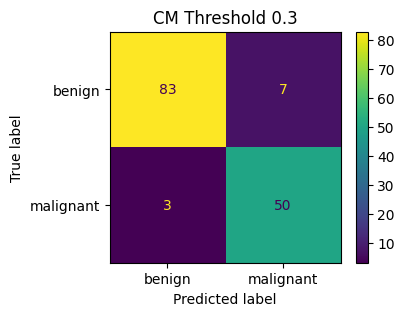


THRESHOLD = 0.5
Confusion Matrix:
[[85  5]
 [ 8 45]]


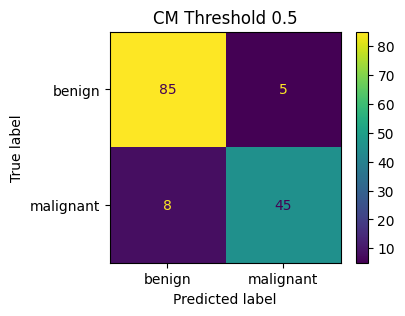


THRESHOLD = 0.7
Confusion Matrix:
[[87  3]
 [12 41]]


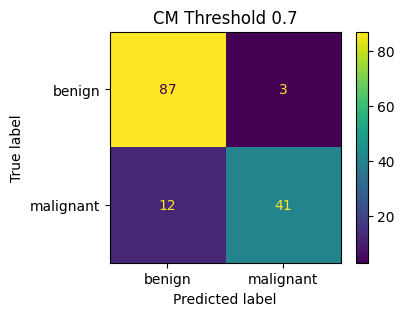

In [51]:
threshold_list = [0.3, 0.5, 0.7]
hasil_threshold = []

for threshold in threshold_list:
    print(f"\nTHRESHOLD = {threshold}")
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_threshold)
    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "malignant"])
    fig, ax = plt.subplots(figsize=(4,3))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(f"CM Threshold {threshold}")
    ax.grid(False)
    plt.show()

In [56]:
for threshold in threshold_list:
    # Prediksi berdasarkan threshold saat ini
    y_pred_threshold = (y_prob >= threshold).astype(int)

    # Evaluation Metrics
    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    print(f"THRESHOLD = {threshold}")

    # Metrics
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-score :", round(f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred_threshold,
        zero_division=0
    ))

    # Simpan hasil
    hasil_threshold.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

THRESHOLD = 0.3
Accuracy : 0.9301
Precision: 0.8772
Recall   : 0.9434
F1-score : 0.9091

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94        90
           1       0.88      0.94      0.91        53

    accuracy                           0.93       143
   macro avg       0.92      0.93      0.93       143
weighted avg       0.93      0.93      0.93       143

THRESHOLD = 0.5
Accuracy : 0.9091
Precision: 0.9
Recall   : 0.8491
F1-score : 0.8738

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        90
           1       0.90      0.85      0.87        53

    accuracy                           0.91       143
   macro avg       0.91      0.90      0.90       143
weighted avg       0.91      0.91      0.91       143

THRESHOLD = 0.7
Accuracy : 0.8951
Precision: 0.9318
Recall   : 0.7736
F1-score : 0.8454

Classification Report:
             

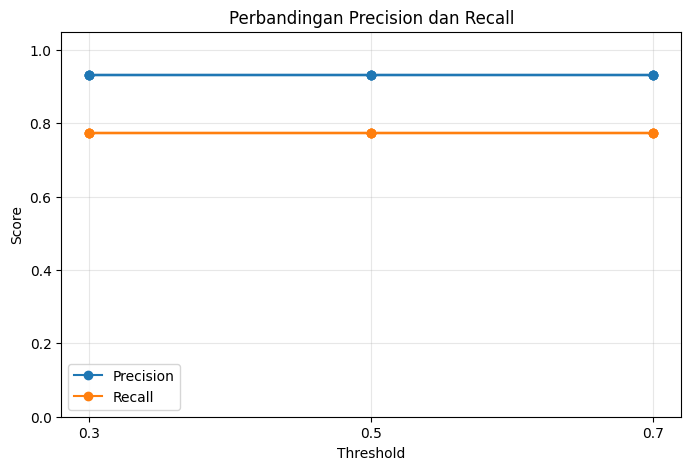

In [44]:
# Visualisasi precision dan recall
plt.figure(figsize=(8, 5))

plt.plot(
    hasil_threshold_df["Threshold"],
    hasil_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    hasil_threshold_df["Threshold"],
    hasil_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Perbandingan Precision dan Recall")
plt.xticks(threshold_list)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

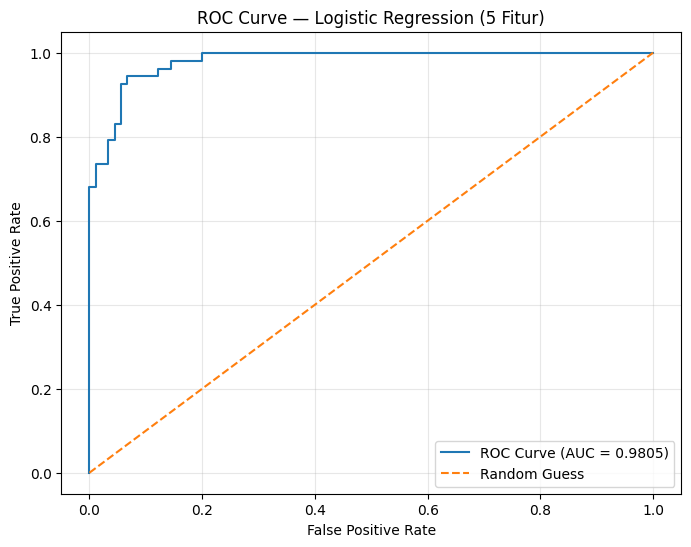

In [46]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_score:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Logistic Regression (5 Fitur)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Interpretasi Hasil Latihan 2

### 1. Logistic Regression dan Probabilitas Prediksi

Pada latihan ini digunakan model logistic regression dengan lima fitur yang sama seperti Latihan 1. Model logistic regression menghasilkan probabilitas prediksi untuk setiap observasi. Pada kasus ini, probabilitas mendekati 1 menunjukkan kemungkinan tumor termasuk malignant, sedangkan
probabilitas mendekati 0 menunjukkan kemungkinan tumor termasuk benign.

Nilai probabilitas tersebut kemudian dibandingkan dengan threshold tertentu untuk menentukan label akhir prediksi.

### 2. Threshold

Threshold merupakan batas probabilitas yang digunakan untuk menentukan kelas prediksi. Pada latihan ini dibandingkan tiga threshold, yaitu 0.3, 0.5, dan 0.7

Secara umum, threshold rendah membuat model lebih mudah memberikan prediksi malignant, sedangkan threshold tinggi membuat model lebih ketat dalam memberikan prediksi malignant.
Perubahan threshold biasanya akan memengaruhi precision,
recall, jumlah false positive, dan jumlah false negative.

### 3. Confusion Matrix

Pada output confusion matrix terlihat hasil klasifikasi model terhadap data testing pada beberapa threshold yang berbeda. Confusion matrix digunakan untuk melihat jenis kesalahan yang dilakukan model, terutama false positive dan false negative.

- Pada threshold 0.3 diperoleh confusion matrix dengen penjelasan berikut:
  - 83 data benign berhasil diprediksi benign,
  - 50 data malignant berhasil diprediksi malignant,
  - terdapat 7 false positive,
  - terdapat 3 false negative.

- Pada threshold 0.5 diperoleh confusion matrix dengen penjelasan berikut:
  - 85 data benign berhasil diprediksi benign,
  - 45 data malignant berhasil diprediksi malignant,
  - terdapat 5 false positive,
  - terdapat 8 false negative.
  
  Artinya jumlah false positive menurun, tetapi false negative meningkat dibanding threshold 0.3.

- Pada threshold 0.7 diperoleh confusion matrix dengen penjelasan berikut:
  - 87 data benign berhasil diprediksi benign,
  - 41 data malignant berhasil diprediksi malignant,
  - terdapat 3 false positive,
  - terdapat 12 false negative.
  
  Artinya model menjadi lebih ketat dalam memberikan prediksi malignant sehingga false positive semakin kecil, tetapi false negative meningkat cukup besar.

### 4. Accuracy

Nilai accuracy berubah pada setiap threshold.
- Threshold 0.3 menghasilkan accuracy sebesar 0.9301.
- Threshold 0.5 menghasilkan accuracy sebesar 0.9091.
- Threshold 0.7 menghasilkan accuracy sebesar 0.8951.

Hasil ini menunjukkan bahwa threshold 0.3 memberikan accuracy tertinggi pada model. Secara umum, accuracy menunjukkan proporsi keseluruhan prediksi yang berhasil dilakukan dengan benar oleh model.

### 5. Precision

Nilai precision berubah sesuai threshold yang digunakan.
- Threshold 0.3 menghasilkan precision sebesar 0.8772.
- Threshold 0.5 menghasilkan precision sebesar 0.9000.
- Threshold 0.7 menghasilkan precision sebesar 0.9318.

Semakin tinggi threshold, precision cenderung meningkat karena model menjadi lebih selektif dalam memberikan prediksi malignant. Hal ini menyebabkan jumlah false positive menurun.

### 6. Recall

Nilai recall juga berubah pada setiap threshold.
- Threshold 0.3 menghasilkan recall sebesar 0.9434.
- Threshold 0.5 menghasilkan recall sebesar 0.8491.
- Threshold 0.7 menghasilkan recall sebesar 0.7736.

Semakin rendah threshold, recall cenderung meningkat karena model lebih mudah memberikan prediksi malignant sehingga lebih banyak kasus malignant berhasil ditemukan. Sebaliknya, ketika threshold dinaikkan, recall menurun karena jumlah false negative meningkat.

### 7. F1-Score

Nilai F1-score pun berubah pada setiap threshold.
- Threshold 0.3 = 0.9091
- Threshold 0.5 = 0.8738
- Threshold 0.7 = 0.8454

Hasil ini menunjukkan bahwa threshold 0.3 memberikan keseimbangan terbaik antara precision dan recall pada model ini.

### 8. Classification Report

Classification report menunjukkan performa model pada masing-masing kelas untuk setiap threshold.

- Pada threshold 0.3, recall kelas malignant mencapai 0.94 yang
menunjukkan bahwa sebagian besar kasus malignant berhasil dideteksi model.
- Pada threshold 0.5, precision dan recall menjadi lebih seimbang, tetapi jumlah false negative meningkat dibanding threshold 0.3.
- Pada threshold 0.7, precision kelas malignant meningkat menjadi sekitar 0.93, tetapi recall turun menjadi sekitar 0.77. Itu artinya model gagal mendeteksi lebih banyak kasus malignant.

### 9. Visualisasi Precision dan Recall

Grafik precision dan recall menunjukkan adanya trade-off antara kedua metrik tersebut. Ketika threshold meningkat, precision meningkat dan recall menurun.

Sebaliknya, ketika threshold diturunkan, recall meningkat dan
precision sedikit menurun. Hal ini sesuai dengan konsep threshold tuning pada logistic regression.

## **Latihan 3 — K-Means**

Pada latihan ini, fokus berpindah dari supervised learning ke unsupervised learning menggunakan dataset Iris. Berbeda dengan logistic regression yang memiliki label target, pada clustering kita sengaja mengabaikan label tersebut saat proses pelatihan model. Tujuan utama dari latihan ini adalah memahami bagaimana algoritma K-Means membentuk kelompok (cluster) berdasarkan kemiripan fitur numerik tanpa bantuan label kelas.

Latihan ini akan mengeksplorasi beberapa nilai jumlah cluster (K), yaitu K = 2, K = 3, dan K = 4. Setelah itu, setiap hasil clustering akan dievaluasi menggunakan silhouette score untuk mengukur seberapa baik pemisahan antar cluster.

Secara garis besar, latihan ini akan:

- menjalankan K-Means untuk beberapa nilai K (2, 3, 4),
- menghitung silhouette score untuk setiap K,
- membandingkan kualitas cluster berdasarkan metrik tersebut.

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# Standardisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

In [108]:
# 1. K-Means untuk K = 2, 3, 4
k_values = [2, 3, 4]
silhouette_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_results.append(score)

    print(f"K = {k}")
    print("Silhouette Score:", round(score, 4))
    print("Inertia:", round(kmeans.inertia_, 4), '\n')

K = 2
Silhouette Score: 0.5818
Inertia: 222.3617 

K = 3
Silhouette Score: 0.4599
Inertia: 139.8205 

K = 4
Silhouette Score: 0.3869
Inertia: 114.0925 



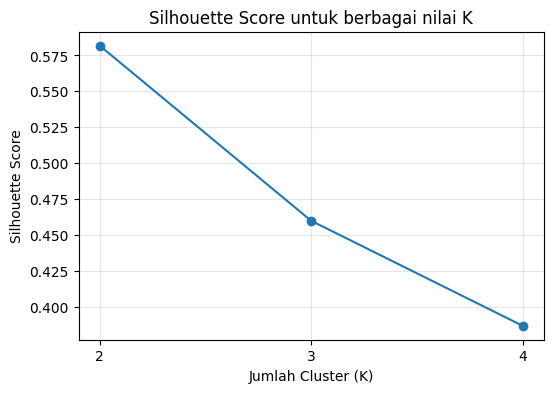

In [110]:
# 2. Visualisasi Silhouette Score
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_results, marker="o")
plt.title("Silhouette Score untuk berbagai nilai K")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

## Interpretasi Hasil Latihan 3

Pada hasil percobaan K-Means dengan dataset Iris dataset, dilakukan pengujian untuk tiga nilai jumlah cluster, yaitu K = 2, K = 3, dan K = 4. Setiap konfigurasi dievaluasi menggunakan silhouette score dan inertia untuk melihat kualitas pemisahan cluster serta tingkat kekompakan data di dalam masing-masing cluster.

### 1. Hasil Silhouette Score dan Inertia

Dari output diperoleh:
- K = 2
  - Silhouette Score = 0.5818
  - Inertia = 222.3617
- K = 3
  - Silhouette Score = 0.4599
  - Inertia = 139.8205
- K = 4
  - Silhouette Score = 0.3869
  - Inertia = 114.0925

**Interpretasi Silhouette Score:**

Silhouette score digunakan untuk mengukur seberapa baik data berada dalam cluster-nya dibandingkan dengan cluster lain.
- Nilai 0.58 pada K = 2 menunjukkan bahwa pemisahan cluster cukup jelas dan paling baik dibandingkan K lainnya.
- Ketika jumlah cluster dinaikkan menjadi K = 3, skor turun menjadi 0.46, yang berarti struktur cluster mulai kurang optimal meskipun masih cukup baik.
- Pada K = 4, skor turun lagi menjadi 0.38, yang menunjukkan bahwa pembagian cluster menjadi terlalu granular sehingga overlap antar cluster semakin besar.

**Interpretasi Inertia:**

Inertia menunjukkan total jarak kuadrat antara data dan centroid cluster (semakin kecil semakin baik). Inertia turun dari 222 menjadi 139 lalu menjadi 114 saat K meningkat.
Penurunan ini normal karena semakin banyak cluster, jarak dalam cluster pasti semakin kecil.

Namun, penurunan inertia tidak cukup untuk menentukan K terbaik. Silhouette score tetap perlu dilihat untuk menjaga keseimbangan antara kekompakan dan pemisahan cluster.

### 2. Plot Silhouette Score

Pada grafik, diketahui bahwa sumbu X adalah jumlah cluster (K) dan sumbu Y adalah silhouette score. Grafik menunjukkan pola menurun seiring meningkatnya K, dengan titik tertinggi ada pada K = 2 kemudian turun pada K = 3 dan K = 4.

Ini mengimplementasikan bahwa struktur alami data lebih sederhana, dan terlalu banyak cluster justru membuat pemisahan tidak stabil.

## **Latihan 4 — Interpretasi Cluster**

Pada latihan ini, kita melanjutkan hasil clustering dari K-Means pada dataset Iris dengan memilih K = 3 sebagai konfigurasi utama. Fokus utama tidak lagi pada pembentukan model, tetapi pada interpretasi hasil clustering. Hal ini penting karena dalam unsupervised learning, nilai utama bukan hanya mendapatkan cluster, tetapi memahami karakteristik dari setiap kelompok yang terbentuk.

Latihan ini akan menghitung rata-rata setiap fitur pada masing-masing cluster untuk melihat pola perbedaan antar kelompok. Melalui cara ini, kita bisa mengidentifikasi cluster mana yang memiliki ukuran petal terbesar, terkecil, serta bagaimana distribusi karakteristik masing-masing cluster.

In [113]:
# 1. K-Means dengan K=2, K=3, dan K=4
iris_df = X_iris.copy()

kmeans2 = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters2 = kmeans2.fit_predict(X_scaled)
iris_df["cluster2"] = clusters2

kmeans3 = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters3 = kmeans3.fit_predict(X_scaled)
iris_df["cluster3"] = clusters3

kmeans4 = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters4 = kmeans4.fit_predict(X_scaled)
iris_df["cluster4"] = clusters4

print("Distribusi cluster:")
print(iris_df["cluster2"].value_counts().sort_index())
print(iris_df["cluster3"].value_counts().sort_index())
print(iris_df["cluster4"].value_counts().sort_index())

Distribusi cluster:
cluster2
0    100
1     50
Name: count, dtype: int64
cluster3
0    53
1    50
2    47
Name: count, dtype: int64
cluster4
0    47
1    53
2    28
3    22
Name: count, dtype: int64


In [96]:
# 2. Rata-rata fitur per cluster
cluster_profile_2 = iris_df.groupby("cluster2").mean()
cluster_profile_3 = iris_df.groupby("cluster3").mean()
cluster_profile_4 = iris_df.groupby("cluster4").mean()

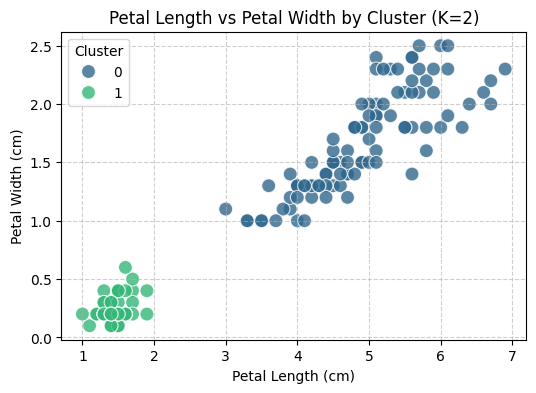

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster3,cluster4
cluster2,,,,,,
0,6.262,2.872,4.906,1.676,0.94,0.53
1,5.006,3.428,1.462,0.246,1.00,2.44


In [97]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster2',
    data=iris_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Petal Length vs Petal Width by Cluster (K=2)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

cluster_profile_2

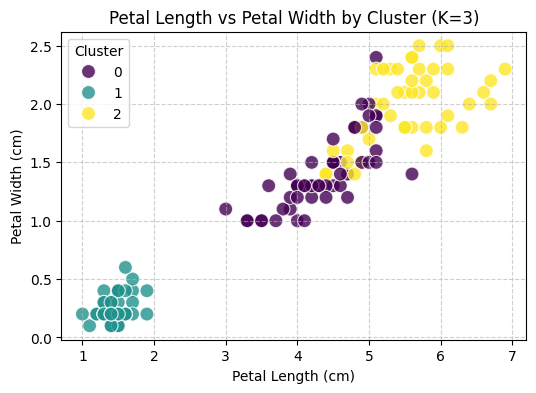

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster2,cluster4
cluster3,,,,,,
0,5.801887,2.673585,4.369811,1.413208,0.0,1.00
1,5.006000,3.428000,1.462000,0.246000,1.0,2.44
2,6.780851,3.095745,5.510638,1.972340,0.0,0.00


In [98]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster3',
    data=iris_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Petal Length vs Petal Width by Cluster (K=3)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

cluster_profile_3

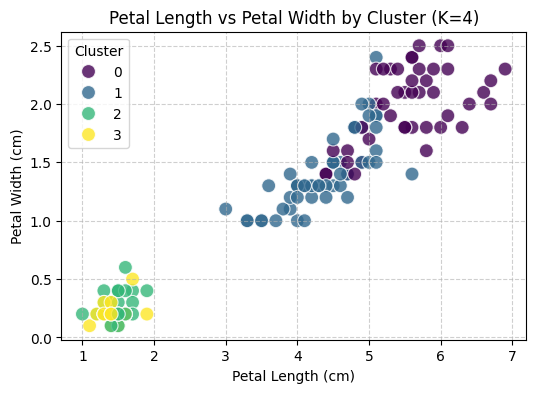

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),cluster2,cluster3
cluster4,,,,,,
0,6.780851,3.095745,5.510638,1.972340,0.0,2.0
1,5.801887,2.673585,4.369811,1.413208,0.0,0.0
2,5.225000,3.678571,1.475000,0.271429,1.0,1.0
3,4.727273,3.109091,1.445455,0.213636,1.0,1.0


In [99]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x='petal length (cm)',
    y='petal width (cm)',
    hue='cluster4',
    data=iris_df,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Petal Length vs Petal Width by Cluster (K=4)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

cluster_profile_4

In [103]:
# 3. Analisis ukuran petal
petal_length_col = "petal length (cm)"
petal_width_col = "petal width (cm)"

for i in [2, 3, 4]:
    profile = iris_df.groupby(f"cluster{i}").mean()
    profile["petal_size_mean"] = (
        profile["petal length (cm)"] + profile["petal width (cm)"]
    ) / 2

    print(f"Cluster{i} terbesar:", profile["petal_size_mean"].idxmax())
    print(f"Cluster{i} terkecil:", profile["petal_size_mean"].idxmin())

Cluster2 terbesar: 0
Cluster2 terkecil: 1
Cluster3 terbesar: 2
Cluster3 terkecil: 1
Cluster4 terbesar: 0
Cluster4 terkecil: 3


## Interpretasi Hasil Latihan 4

### 1. Distribusi Cluster

Dari hasil distribusi:
- K = 2
  - Cluster 0 = 100 data
  - Cluster 1 = 50 data
- K = 3
  - Cluster 0 = 53 data
  - Cluster 1 = 50 data
Cluster 2 = 47 data
- K = 4
  - Cluster 0 = 47 data
  - Cluster 1 = 53 data
  - Cluster 2 = 28 data
  - Cluster 3 = 22 data

Pada K = 2, data terbagi menjadi dua kelompok besar. Kemudian pada K = 3, pembagian menjadi lebih seimbang dan natural.
Selanjutnya pada K = 4, cluster menjadi lebih kecil dan terpecah, terutama cluster 3 yang hanya 22 data.

### 2. Cluster Profile dan Scatter Plot (Petal Length vs Petal Width)

Berdasarkan hasil groupby mean, cluster dengan petal terbesar selalu konsisten muncul sebagai cluster dengan nilai petal length & width tertinggi. Sementara itu, cluster dengan petal terkecil
memiliki nilai petal sangat kecil dan terpisah jelas dari cluster lain

Pada ketiga visualisasi scatter plot:

- K = 2

  Terlihat dua kelompok besar, yaitu kelompok dengan petal kecil dan kelompok dengan petal besar. Pemisahan cukup jelas tetapi masih terlalu umum.

- K = 3

  Terlihat tiga kelompok yang lebih terstruktur,yaitu cluster petal kecil, cluster petal sedang, dan cluster petal besar. Pemisahan paling “natural” secara visual.

- K = 4

  Cluster mulai saling tumpang tindih. Ada cluster kecil yang berada di area transisi dan menunjukkan pembagian terlalu detail sehingga kurang stabil.

### 3. Cluster Terbesar dan Terkecil

Hasil output menunjukkan bahwa pada K2, cluster terbesar adalah cluster 0, sedangkan cluster terkecil adalah cluster 1. Pada K3, cluster terbesar adalah cluster 2 dan cluster terkecil adalah cluster 1. Sementara itu, pada K4, cluster terbesar adalah cluster 0 dan cluster terkecil adalah cluster 3.

Secara interpretasi, cluster terbesar biasanya berisi data dengan karakteristik yang paling umum atau paling sering muncul dalam dataset. Sebaliknya, cluster terkecil cenderung berisi data dengan karakteristik yang lebih spesifik, berbeda, atau bisa juga merepresentasikan struktur yang lebih jarang muncul dalam data, termasuk kemungkinan adanya pola yang lebih unik dibandingkan kelompok lainnya.

---
## Kesimpulan Umum Latihan 3 dan 4

Berdasarkan hasil K-Means clustering pada dataset Iris dataset dengan beberapa nilai K (2, 3, dan 4), dapat disimpulkan bahwa kualitas clustering tidak hanya ditentukan oleh penurunan inertia, tetapi terutama oleh keseimbangan antara kekompakan cluster dan pemisahan antar cluster yang tercermin dari silhouette score serta interpretasi visual dan fitur.

Secara numerik, K = 2 menghasilkan silhouette score tertinggi (0.5818), yang menunjukkan pemisahan cluster paling jelas secara matematis. Namun, dari sisi interpretasi data, K = 2 terlalu menyederhanakan struktur karena hanya membagi data menjadi dua kelompok besar tanpa menangkap variasi alami dalam data Iris. Sementara itu, K = 4 menghasilkan silhouette score terendah (0.3869), yang menunjukkan bahwa data menjadi terlalu terfragmentasi sehingga overlap antar cluster semakin besar dan struktur menjadi kurang stabil.

Di antara ketiganya, K = 3 memberikan keseimbangan terbaik secara praktis. Meskipun silhouette score-nya (0.4599) tidak setinggi K = 2, hasil visualisasi scatter plot menunjukkan pemisahan yang paling natural, di mana cluster petal kecil, sedang, dan besar terlihat lebih jelas dan sesuai dengan struktur biologis data Iris. Selain itu, distribusi cluster juga lebih seimbang dibandingkan K = 4 yang cenderung menghasilkan cluster kecil yang kurang stabil.

Dengan demikian, meskipun secara metrik K = 2 adalah yang terbaik, **K = 3 dipilih sebagai jumlah cluster paling masuk akal secara keseluruhan** karena memberikan kompromi terbaik antara kualitas clustering secara statistik.
